# 04 · H2: Do oil price rises and falls have symmetric effects? (NARDL)

**Model.** Nonlinear ARDL (Shin, Yu & Greenwood-Nimmo 2014). The log oil price is split into two partial sums:
- **P⁺**, the cumulative sum of all *increases*.
- **P⁻**, the cumulative sum of all *decreases*.

Δln ToT_t = c + α·ln ToT_{t−1} + θ⁺·P⁺_{t−1} + θ⁻·P⁻_{t−1} + π⁺·ΔP⁺_t + π⁻·ΔP⁻_t + controls + ε_t

**What is tested:**
- Long-run effects: L⁺ = −θ⁺/α and L⁻ = −θ⁻/α.
- **Long-run symmetry:** Wald test of θ⁺ = θ⁻ (equivalently L⁺ = L⁻).
- **Short-run symmetry:** Wald test of π⁺ = π⁻.

**Sign convention.** Both L⁺ and L⁻ are negative if oil hurts India's ToT. With L⁻ < 0, a 1% oil price *fall* (P⁻ down by 0.01) raises ToT by |L⁻|%.

**Why it matters (L16).** A cartel defends price floors, and refining margins behave differently in gluts and crunches. If India gains less from falls than it loses from rises, oil volatility alone is costly.

In [1]:
# Shared setup: the helper modules live in ../src (chart style, econometrics helpers, data loader)
import sys; sys.path.append("../src")
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from style import *
import econ
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
m, a, c = econ.load()

In [2]:
d = np.log(a.loc[1970:2024, ["tot_gs_na", "real_oil_avg", "real_nonenergy"]]).rename(columns={"tot_gs_na": "y", "real_oil_avg": "x", "real_nonenergy": "z"})
base = econ.nardl(d, "y", "x", controls=("z",))
print(base["fit"].summary().tables[1])
print(f"N = {base['N']} | L+ = {base['LR_pos']:.3f}, L- = {base['LR_neg']:.3f}, Wald LR symmetry p = {base['p_LR_sym']:.3f}")
print(f"Short-run: pi+ = {base['SR_pos']:.3f}, pi- = {base['SR_neg']:.3f}, Wald SR symmetry p = {base['p_SR_sym']:.3f}")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.5773      0.619      4.163      0.000       1.331       3.823
y_1           -0.4763      0.116     -4.102      0.000      -0.710      -0.243
xp_1          -0.0770      0.028     -2.736      0.009      -0.134      -0.020
xn_1          -0.1085      0.040     -2.682      0.010      -0.190      -0.027
dxp           -0.2708      0.064     -4.199      0.000      -0.401      -0.141
dxn           -0.2150      0.083     -2.590      0.013      -0.382      -0.048
z_1           -0.0615      0.055     -1.124      0.267      -0.172       0.049
dz             0.2565      0.113      2.271      0.028       0.029       0.484
N = 54 | L+ = -0.162, L- = -0.228, Wald LR symmetry p = 0.035
Short-run: pi+ = -0.271, pi- = -0.215, Wald SR symmetry p = 0.620


## Robustness of the asymmetry result

In [3]:
rows = []
cases = [("Baseline FY1970-2024, with non-oil control", "tot_gs_na", "real_oil_avg", 1970, 2024, ("z",), False),
         ("No control", "tot_gs_na", "real_oil_avg", 1970, 2024, (), False),
         ("Brent", "tot_gs_na", "real_brent", 1970, 2024, ("z",), False),
         ("Extra lag of ΔToT", "tot_gs_na", "real_oil_avg", 1970, 2024, ("z",), True),
         ("FY1975-2024", "tot_gs_na", "real_oil_avg", 1975, 2024, ("z",), False),
         ("FY1980-2024 (drops the 1970s shocks)", "tot_gs_na", "real_oil_avg", 1980, 2024, ("z",), False),
         ("Merchandise ToT FY1994-2024", "ntt_rbi_chained", "real_oil_avg", 1994, 2024, ("z",), False)]
for name, y, x, s, e, ctrl, lag in cases:
    dd = np.log(a.loc[s:e, [y, x, "real_nonenergy"]]).rename(columns={y: "y", x: "x", "real_nonenergy": "z"})
    r = econ.nardl(dd, "y", "x", controls=ctrl, extra_ylag=lag)
    rows.append({"Specification": name, "N": r["N"], "L+ (rise)": r["LR_pos"], "L- (fall)": r["LR_neg"],
                 "p LR symmetry": r["p_LR_sym"], "π+ (SR rise)": r["SR_pos"], "π- (SR fall)": r["SR_neg"],
                 "p SR symmetry": r["p_SR_sym"]})
tab = pd.DataFrame(rows).set_index("Specification")
save_table(tab, "t06_nardl_asymmetry")
tab

,N,L+ (rise),L- (fall),p LR symmetry,π+ (SR rise),π- (SR fall),p SR symmetry
Specification,,,,,,,
"Baseline FY1970-2024, with non-oil control",54,-0.162,-0.228,0.035,-0.271,-0.215,0.620
No control,54,-0.199,-0.285,0.017,-0.233,-0.192,0.735
Brent,54,-0.157,-0.221,0.036,-0.261,-0.217,0.693
Extra lag of ΔToT,53,-0.119,-0.180,0.051,-0.239,-0.215,0.831
FY1975-2024,49,-0.106,-0.161,0.077,-0.217,-0.204,0.913
FY1980-2024 (drops the 1970s shocks),44,-0.114,-0.145,0.275,-0.245,-0.172,0.537
Merchandise ToT FY1994-2024,30,-0.187,-0.075,0.131,-0.234,-0.308,0.746


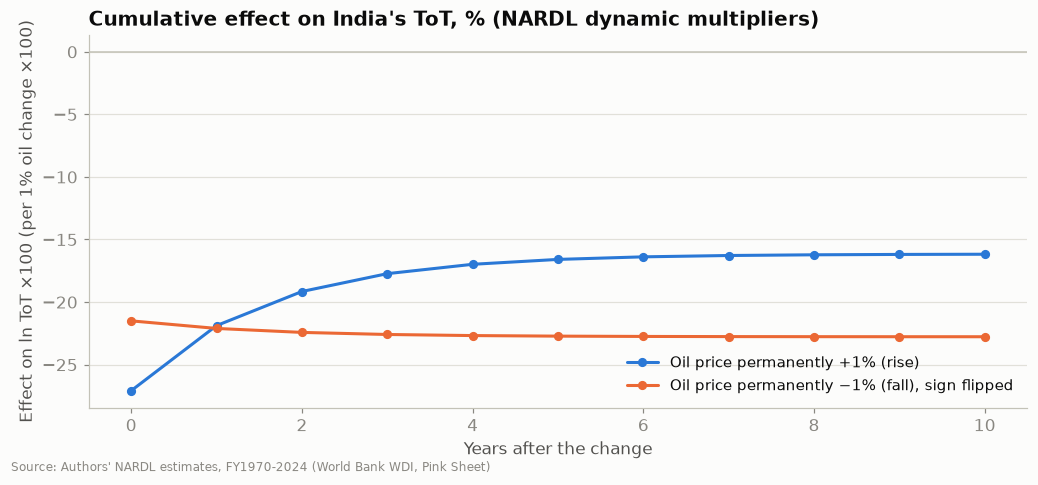

In [4]:
mult = econ.nardl_multipliers(base, horizons=10)
fig, ax = plt.subplots(figsize=(9.5, 4.4))
h = mult.index
ax.plot(h, 100 * mult["rise"], color=BLUE, marker="o", ms=5, label="Oil price permanently +1% (rise)")
ax.plot(h, -100 * mult["fall"], color=ORANGE, marker="o", ms=5, label="Oil price permanently −1% (fall), sign flipped")
ax.axhline(0, color=AXIS, lw=1)
ax.set_title("Cumulative effect on India's ToT, % (NARDL dynamic multipliers)")
ax.set_xlabel("Years after the change"); ax.set_ylabel("Effect on ln ToT ×100 (per 1% oil change ×100)")
ax.legend(loc="lower right")
fig.tight_layout()
save(fig, "fig09_nardl_multipliers", "Authors' NARDL estimates, FY1970-2024 (World Bank WDI, Pink Sheet)")
plt.show()

**Reading and conclusion for H2.**
- **Short run:** the response to rises and falls is statistically the **same** in every specification (all p-values large).
- **Long run:** the baseline finds a larger response to *falls* than to rises (p ≈ 0.04). This is **not robust**: it weakens with an extra lag, disappears once the 1970s shocks are dropped (FY1980–2024), and the merchandise series points the other way (not significant).
- **Conclusion:** H2 is **not supported**. India's ToT responds roughly symmetrically to oil price rises and falls. For policy, this means India gains from oil price falls about as much as it loses from rises, so smoothing the shocks (buffers, reserves) is the issue rather than a one-sided bias.